# A Simple Tutorial for TIC

Welcome to **TIC (Temporal Inference of Cells)** — a Python toolkit for **graph‑based pseudo‑time analysis**, **micro‑environment feature engineering**, and **causal inference** on spatial‑omics data.

This notebook walks you through a *minimal‑yet‑complete* workflow **from raw spatial transcriptomics data to causal insights**.  
Each section pairs **concise code** with **detailed narrative** so you can **understand *why***, not just *how*.



## 1 Installation

TIC is tested with **Python ≥ 3.10** on Linux/macOS.  
It depends on **NumPy**, **SciPy**, **scanpy**, **PyTorch (optional)**, and a few light utilities.

```bash
# clone the repository
git clone https://github.com/cellethology/tic.git
cd tic

# develop mode install ‑‑ keeps your working copy editable
pip install -e .
```

> **Tip** If you prefer a fully reproducible environment, see `requirements.txt` for a Conda recipe.



## 2 Load single‑cell data (AnnData)

TIC expects a standard `AnnData` object with at least:

| field | description |
|-------|-------------|
| `X`   | **cells × genes** expression matrix (dense or CSR) |
| `var` | gene meta‑data; *at minimum* an `index` of gene names |
| `obsm['spatial']` | **x / y** coordinates per cell (pixels or μm) |

*Optional* — but recommended:

* `obs['cell_type']` → categorical cell identities used by certain feature extractors


In [1]:
import warnings
warnings.filterwarnings('ignore')  

In [2]:

# Download & cache the public CODEX‑UPMC dataset (~500 MB)  
# The first call may take 1-10 minutes(depends on your network speed); subsequent calls reuse ~/.cache/tic/
from tic.data import load_region

adata = load_region()
print(adata)
print("Unique cell types:", adata.obs['cell_type'].unique())


2025-05-30 10:21:25,990 INFO Extracting upmc_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_upmc
2025-05-30 10:21:25,990 | INFO     | tic.data.io | Extracting upmc_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_upmc


Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_upmc/upmc_raw_data.zip


2025-05-30 10:21:29,933 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
2025-05-30 10:21:29,933 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-05-30 10:21:29,934 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-05-30 10:21:30,243 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
Loaded upmc (UPMC_c001_v001_r001_reg001): 4360 cells * 22 biomarkers.
2025-05-30 10:21:30,268 | INFO     | tic.data.codex.loader | Loaded upmc (UPMC_c001_v001_r001_reg001): 4360 cells * 22 biomarkers.


View of AnnData object with n_obs × n_vars = 4360 × 22
    obs: 'cell_type', 'size'
    uns: 'tissue_id', 'data_level'
    obsm: 'spatial'
Unique cell types: ['Naive immune cell' 'Macrophage' 'Stromal / Fibroblast' 'CD4 T cell'
 'Tumor (Ki67+)' 'Tumor (CD20+)' 'Tumor (CD21+)' 'Tumor (Podo+)' 'B cell'
 'Tumor' 'APC' 'Lymph vessel' 'CD8 T cell' 'Unassigned' 'Vessel'
 'Granulocyte' 'Tumor (CD15+)']



### Clean the local dataset cache

```bash
# nuke *all* cached datasets
rm -rf ~/.cache/tic
```

or in Python:

```python
from tic.data import list_datasets, remove_cache, remove_dataset
list_datasets()      # see what's cached
remove_dataset("codex_upmc")   # delete one dataset
# remove_cache()     # delete everything
```



## 3 Micro‑environment feature extraction

TIC formalises feature engineering as **(i) neighbourhood definition** → **(ii) feature recipe**.

1. **Graph construction** — `tic.graph.pp.compute_neighbors`  
   *Examples*: *Voronoi* adjacency, *k‑NN*, *radius* graph …
2. **Sub‑graph extraction** — `tic.graph.tl.extract_subgraph`  
   Strategies ranging from simple *k‑hop* BFS to *torch‑geometric*’s fast CUDA kernels.
3. **Feature recipe** — a named bundle of extractors (gene counts, composition, …).

Below we use the built‑in recipe **`tme_default`** and a *radius* subgraph around **tumour cells**.


In [3]:

from tic.wrappers import FeatureWrapper
from tic.graph.utils import estimate_radius

# Heuristic: radius giving ~30 neighbours per centre cell
suggested_r = estimate_radius(adata)
print(f"Suggested radius ≈ {suggested_r:.1f} pixels")

custom_recipe = {
    "composition": {},
    "celltype_gene_count": {},# for causal inference
}
fw = FeatureWrapper(
    recipe=custom_recipe,
    centre_types=["Tumor"],                 # tumour cells as micro‑environment centres
    graph_params={'method': 'voronoi'},     # image‑level graph
    subgraph_params={'strategy': 'radius', 'radius': suggested_r},
)
fea_adata = fw.fit(adata)
fea_adata


Suggested radius ≈ 100.6 pixels


Extracting subgraphs: 100%|██████████| 497/497 [00:00<00:00, 841.35it/s]


AnnData object with n_obs × n_vars = 497 × 22
    obs: 'cell_type', 'size'
    uns: 'feature_modes', 'graph_params', 'subgraph_params', 'X_predictors_names', 'X_predictors_meta'
    obsm: 'composition', 'celltype_gene_count', 'X_predictors'


## 4 Pseudo‑time inference

TIC offers a **plug‑and‑play wrapper** around a multi‑step pipeline:

| step | default | purpose |
|------|---------|---------|
| Dimensionality reduction | PCA | compress high‑D features |
| Clustering | k‑means | discover meta‑states along transition |
| Graph learning | Slingshot | principal curve through clusters |
| Metrics | monotonicity / trend | quantify biomarker dynamics |

Use `.plot()` to colour the embedding by pseudotime or cluster labels.


2025-05-30 10:21:31,367 | INFO     | tic.pipeline.pseudotime | Pseudotime pipeline order: ['_ClusterStep', '_DRStep', '_PseudotimeStep', '_MetricStep']
100%|██████████| 10/10 [00:00<00:00, 21.66it/s]


,biomarker,mono_method,mono_correlation,mono_p_value,trend_method,trend_trend,trend_statistic,trend_p_value
0,CD11b,spearman,-0.013337,0.766782,mann_kendall,no_trend,1.883834,0.059587
1,CD14,spearman,0.120935,0.006951,mann_kendall,decreasing,-2.239351,0.025133
2,CD15,spearman,-0.182814,0.000041,mann_kendall,decreasing,-3.003374,0.002670
3,CD163,spearman,-0.114755,0.010458,mann_kendall,no_trend,1.450185,0.147007
4,CD20,spearman,-0.053007,0.238172,mann_kendall,no_trend,1.147928,0.250998


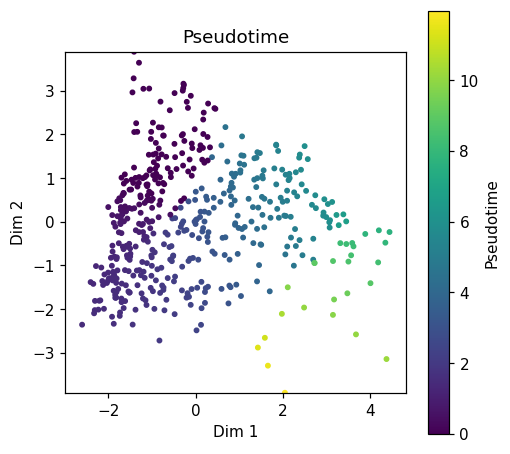

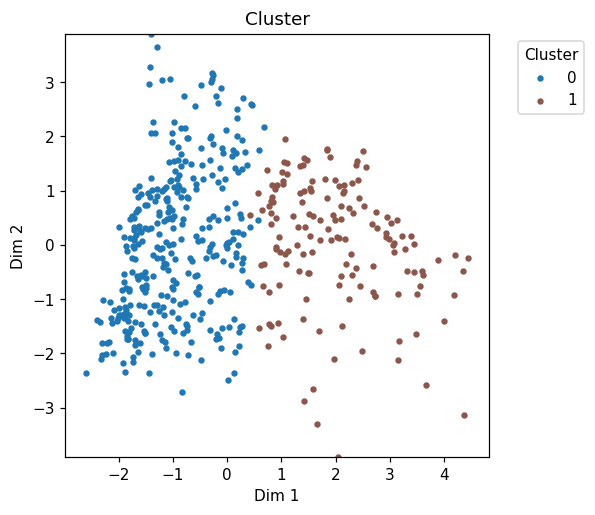

In [4]:

from tic.wrappers import PseudotimeWrapper

ptw = PseudotimeWrapper(
    rep_key="composition",        # 30‑D micro‑environment composition vectors
    output_dir="example_out",     # all artefacts saved here
)
pseudotime_adata = ptw.fit(fea_adata)

# quick visual checks
ptw.plot(kind="pseudotime")
ptw.plot(kind="cluster")

# inspect summary metrics
ptw.metrics.head()



## 5 Visualisation utilities

TIC ships opinionated plots for common tasks.

### 5.1 Monotonicity bar‑plot
Highlight top‑n biomarkers, always showing known epithelial / mesenchymal markers.


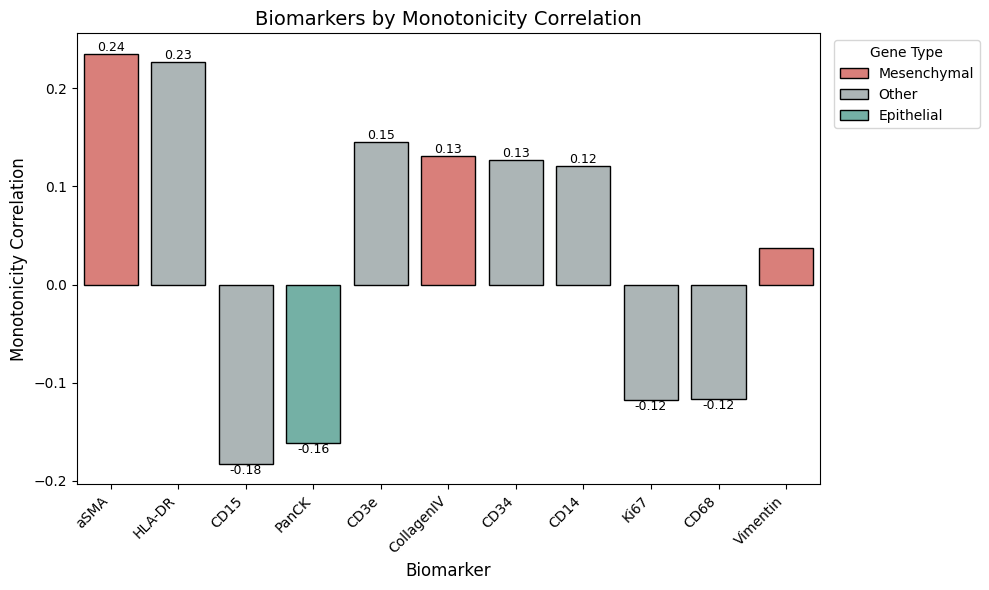

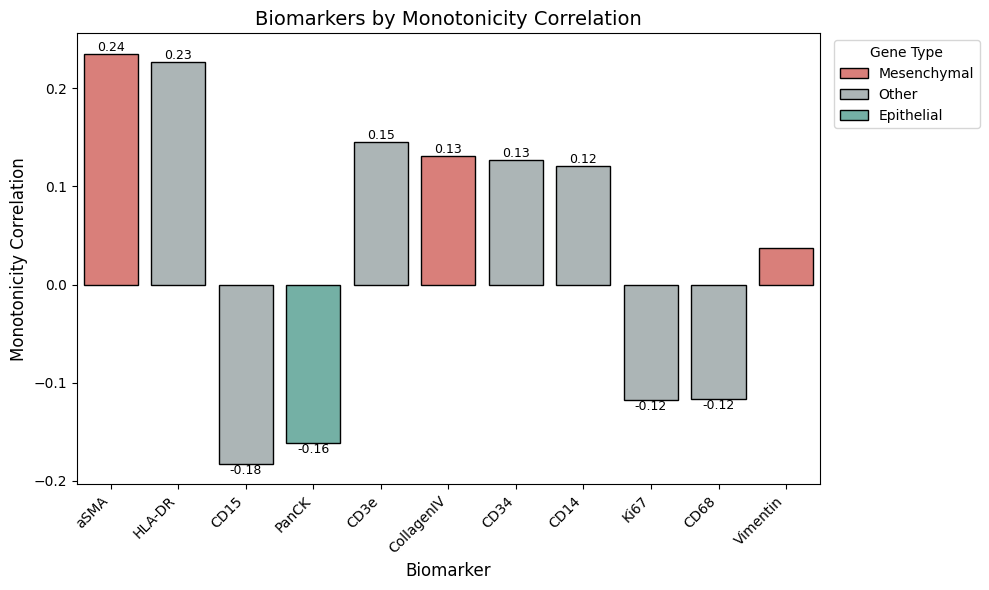

In [5]:

from tic.plotting import plot_monotonicity_metrics_bar
from utils.dataset.codex_upmc import UPMC_EPITHELIAL_GENES, UPMC_MESENCHYMAL_GENES

plot_monotonicity_metrics_bar(
    metrics=ptw.metrics,
    show_top_n=10,
    epithelial_genes=UPMC_EPITHELIAL_GENES,
    mesenchymal_genes=UPMC_MESENCHYMAL_GENES,
    save_path="example_out/monotonicity_bar.png",
)


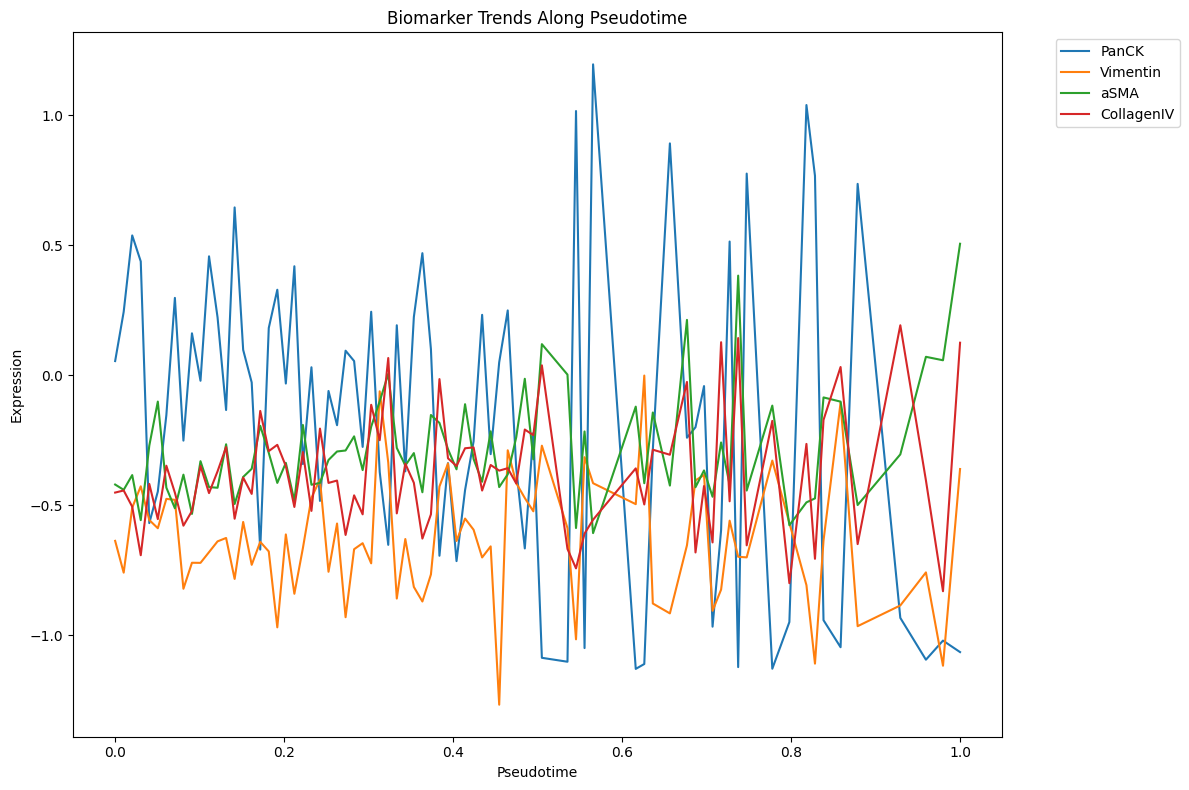

<Axes: title={'center': 'Biomarker Trends Along Pseudotime'}, xlabel='Pseudotime', ylabel='Expression'>

In [11]:
from tic.plotting import plot_biomarker_trends
plot_biomarker_trends(
    adata=pseudotime_adata,
    selected_biomarkers=UPMC_EPITHELIAL_GENES + UPMC_MESENCHYMAL_GENES,
    x_transform="bin+normalize",
    bins=100,
)


### 5.2 Biomarker trajectories


In [6]:

from tic.plotting import plot_biomarker_trends

plot_biomarker_trends(
    adata=pseudotime_adata,
    selected_biomarkers=UPMC_EPITHELIAL_GENES + UPMC_MESENCHYMAL_GENES,
    x_transform="bin+normalize",
    y_transform="normalize",
    bins=100,
    save_path="example_out/biomarker_vs_pt.png",
)



## 6 Causal inference

Finally, test **putative regulators → outcome biomarker** relationships across pseudo‑time bins.

Below we estimate **time‑lagged Granger causality** of micro‑environmental predictors on the *PanCK* epithelial marker.


No statistically significant predictors found (p ≥ 0.050).


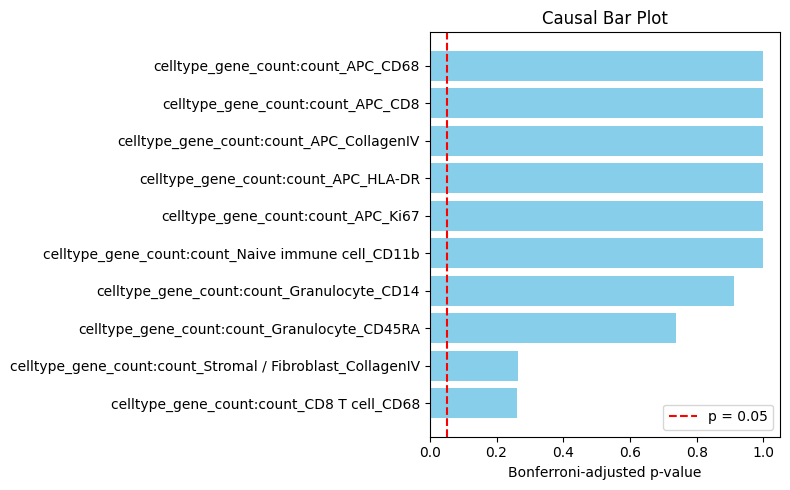

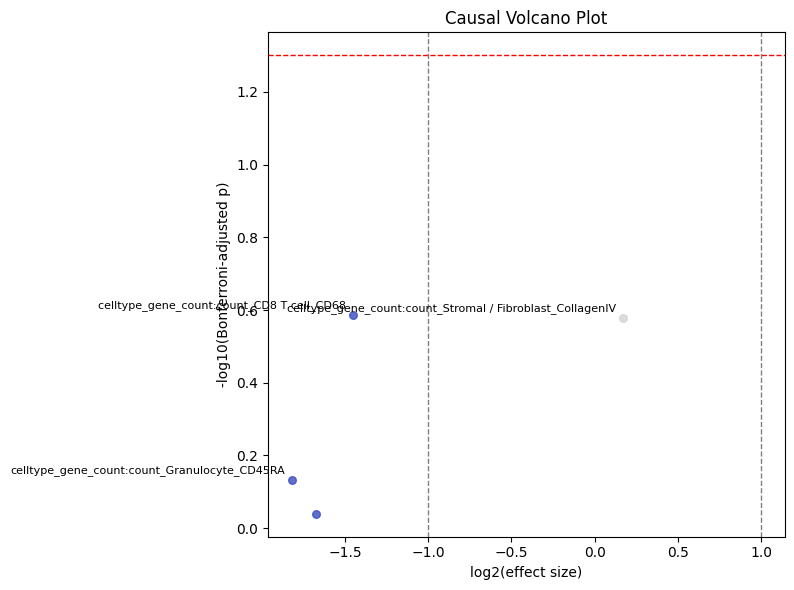

In [7]:

from tic.wrappers.causal import CausalWrapper

cw = CausalWrapper(
    outcome="PanCK",
    include_extractors=("celltype_gene_count",),  # focus on cell‑type densities
    method="granger_causality",
    bins=100,
    method_kwargs=dict(maxlag=3),
)
causal_adata = cw.fit(pseudotime_adata)

# three complementary visualisations
cw.plot(causal_adata, kind="bar")
cw.plot(causal_adata, kind="volcano")
cw.plot(causal_adata, kind="heatmap") # if no significant results, it will plot nothing


In [8]:
print(cw.results.get("celltype_gene_count:count_Naive immune cell_CD11b"))

{'estimated_effect': None, 'raw_pvalues': {1: 0.7407905667275878, 2: 0.6957497534389236, 3: 0.28152160211356414}, 'adjusted_pvalues': {1: 1.0, 2: 1.0, 3: 0.8445648063406924}, 'best_lag': 3, 'p_value': 0.8445648063406924, 'detailed_stats': {1: {'f_stat': 0.11025687187508897, 'raw_p_value': 0.7407905667275878, 'adjusted_p_value': 1.0, 'df_denom': 74.0, 'df_num': 1, 'coefficients': [0.13921665714267295, 0.011662293249730254, 0.054260363510180126]}, 2: {'f_stat': 0.3646250642119784, 'raw_p_value': 0.6957497534389236, 'adjusted_p_value': 1.0, 'df_denom': 71.0, 'df_num': 2, 'coefficients': [0.1509211846520944, -0.10220207710057101, 0.013460174959249279, 0.029090281049529116, 0.06274241052875108]}, 3: {'f_stat': 1.3001951695410034, 'raw_p_value': 0.28152160211356414, 'adjusted_p_value': 0.8445648063406924, 'df_denom': 68.0, 'df_num': 3, 'coefficients': [0.16767407062974055, -0.09472835242088587, -0.0775976659627863, 0.010676987477530132, 0.01898499459819957, -0.065317847983083, 0.056690934823

In [9]:
print(cw.results)

{'celltype_gene_count:count_Naive immune cell_CD11b': {'estimated_effect': None, 'raw_pvalues': {1: 0.7407905667275878, 2: 0.6957497534389236, 3: 0.28152160211356414}, 'adjusted_pvalues': {1: 1.0, 2: 1.0, 3: 0.8445648063406924}, 'best_lag': 3, 'p_value': 0.8445648063406924, 'detailed_stats': {1: {'f_stat': 0.11025687187508897, 'raw_p_value': 0.7407905667275878, 'adjusted_p_value': 1.0, 'df_denom': 74.0, 'df_num': 1, 'coefficients': [0.13921665714267295, 0.011662293249730254, 0.054260363510180126]}, 2: {'f_stat': 0.3646250642119784, 'raw_p_value': 0.6957497534389236, 'adjusted_p_value': 1.0, 'df_denom': 71.0, 'df_num': 2, 'coefficients': [0.1509211846520944, -0.10220207710057101, 0.013460174959249279, 0.029090281049529116, 0.06274241052875108]}, 3: {'f_stat': 1.3001951695410034, 'raw_p_value': 0.28152160211356414, 'adjusted_p_value': 0.8445648063406924, 'df_denom': 68.0, 'df_num': 3, 'coefficients': [0.16767407062974055, -0.09472835242088587, -0.0775976659627863, 0.010676987477530132, 0


---

### That’s it!

You have:

1. **Loaded** spatial‑omics data  
2. **Engineered** micro‑environment features  
3. **Inferred** pseudo‑time trajectories  
4. **Visualised** biomarker dynamics  
5. **Quantified** causal drivers

Explore, tweak hyper‑parameters, and plug in your own data.  
Issues & pull‑requests welcome at [github.com/cellethology/tic](https://github.com/cellethology/tic).
